## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
import shap
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  4540 non-null   float64       
 1   CurrentDebt             4540 non-null   float64       
 2   LongTermDebt            4540 non-null   float64       
 3   TotalDebt               4540 non-null   float64       
 4   StockholdersEquity      4540 non-null   float64       
 5   TotalAssets             4540 non-null   float64       
 6   CurrentAssets           4540 non-null   float64       
 7   CurrentLiabilities      4540 non-null   float64       
 8   OperatingCashFlow_TTM   4540 non-null   float64       
 9   InvestingCashFlow_TTM   4540 non-null   float64       
 10  FinancingCashFlow_TTM   4540 non-null   float64       
 11  FreeCashFlow_TTM        4540 non-null   float64       
 12  CapitalExpenditure_TTM  4540 non-null   float64 

## Feature Engineering

Sección para crear variables en la fase de modelado. 
La mayor parte de las variables fue creada en la fase de transformación.

In [3]:
# Calcular las aceleraciones netas (Momento - Tendencia) para variables de crecimiento.
# Una vez calculadas, se eliminan las variables trimestrales (reemplazar=True)
variables_de_crecimiento = ['Revenue_QoQ', 'Ebitda_QoQ', 'Fcf_QoQ', 'CapEx_QoQ']
df = calcular_acceleration_features(df, variables_de_crecimiento, reemplazar= True)

In [4]:
# Variable flag: empresas gigantes
df['IsMegaCap'] = (df['MarketCap'] > 200).astype(int)

In [5]:
# Sectores poco significativos: se agrupan en la categoria "Other"
# Se saltea en la versión actual
#sectores_importantes = ['InformationTechnology', 'Energy']

#df['Sector'] = np.where(df['Sector'].isin(sectores_importantes), df['Sector'], 'Other')

# Se vuelve a convertir en category
#df['Sector'] = df['Sector'].astype('category')

# Modelo de ensamblado de árboles RandomForest

In [6]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores
cols_financieras = obtener_cols_financieras()
variables_no_significativas = [

]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Ticker y fecha
    'Ticker',
    'Date',
    # Totales del mercado
    'TotalMarketAssets',
    'TotalMarketRevenue',
    # Variables que dependen del precio (posibles labels)
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda',
    'MarketCap',
    'EnterpriseValue',
    'Open',
    'Close' # no usar como label, corresponden los precios Open
    ]

# Se define la variable objetivo y las variables predictoras
label = 'Open'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = ['Sector']

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.4525


In [7]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.3153 ± 0.1278


In [8]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
4,num__ReturnOnAssets,0.343175
0,num__Dividends,0.125443
12,num__CapExToRevenue,0.115292
18,num__RelativeAssets_log,0.085737
25,cat__Sector,0.050543
3,num__ReturnOnEquity,0.045679
5,num__DebtToEquity,0.043150
1,num__OperatingMargins,0.041727
19,num__RelativeRevenue_log,0.025851
2,num__ProfitMargins,0.024337


In [9]:
feature_importance_df.tail(10)

,feature,importance
23,num__CapEx_Acceleration,0.005191
13,num__QuarterlyReturn,0.005119
9,num__CapEx_YoY,0.004372
14,num__QuarterlyVariance,0.003901
6,num__Revenue_YoY,0.003406
21,num__Ebitda_Acceleration,0.002261
22,num__Fcf_Acceleration,0.002165
20,num__Revenue_Acceleration,0.001823
24,num__IsMegaCap,0.001374
15,num__MarketCovariance,0.001304


## Aplicacion del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [10]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train = X.iloc[:-len(df['Ticker'].unique())]  # Todos menos la última fecha de cada ticker
y_train = y.iloc[:-len(df['Ticker'].unique())]
X_test = X.iloc[-len(df['Ticker'].unique()):]   # Solo la última fecha de cada ticker
y_test = y.iloc[-len(df['Ticker'].unique()):]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Consolidar resultados individuales en un DataFrame
resultados_df = pd.DataFrame({
    'Ticker': tickers_test,
    'Predicted': y_pred,
    'Observed': y_test
})

# Calcular el residuo para cada predicción
resultados_df['Residuals'] = resultados_df['Predicted'] - resultados_df['Observed']

# Agrupar por ticker
resultados_agrupados = resultados_df.groupby('Ticker')[['Predicted', 'Observed', 'Residuals']].mean()

# Generar el Cluster sobre el promedio de los residuos
resultados_agrupados['Cluster'] = ['PositiveBias' if r >= 0 else 'NegativeBias' 
                                   for r in resultados_agrupados['Residuals']]

# Visualizar
fig = px.scatter(
    resultados_agrupados, 
    x='Observed', 
    y='Predicted', 
    color='Cluster',
    hover_name=resultados_agrupados.index, 
    labels={'Observed':'Valores Reales', 'Predicted':'Predicciones', 'Cluster':'Sesgo del Modelo'},
    title='Predicciones vs Reales (Agrupado por Ticker)'
)

# Línea de identidad perfecta
min_val = resultados_agrupados['Observed'].min()
max_val = resultados_agrupados['Observed'].max()
fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color='black', dash='dash', width=2))
fig.show()

# Estadísticas por cluster a nivel Ticker
over_mask = resultados_agrupados['Cluster'] == 'PositiveBias'
under_mask = resultados_agrupados['Cluster'] == 'NegativeBias'

print("\nEstadísticas por cluster (a nivel de Ticker):")
print(f"Overprediction: {over_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[over_mask, 'Residuals'].mean():.4f}")
print(f"Underprediction: {under_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[under_mask, 'Residuals'].mean():.4f}")


Estadísticas por cluster (a nivel de Ticker):
Overprediction: 218 tickers, residuo medio global: 95.4107
Underprediction: 136 tickers, residuo medio global: -223.3609


In [11]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker   Predicted   Observed  Residuals      Cluster  PercentError
  VRSN 1119.218351 286.109985 833.108366 PositiveBias    291.184652
  FAST  797.679101  43.660000 754.019101 PositiveBias   1727.024973
   DPZ 1023.067873 311.329987 711.737887 PositiveBias    228.612057
  DECK  761.536311 112.430000 649.106310 PositiveBias    577.342621
  PLTR  670.663081 159.979996 510.683085 PositiveBias    319.216839


In [12]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,MarketCovariance,YearsSinceAdded,CurrentRatio_log,RelativeAssets_log,RelativeRevenue_log,Revenue_Acceleration,Ebitda_Acceleration,Fcf_Acceleration,CapEx_Acceleration,IsMegaCap
0,VRSN,1119.218351,286.109985,833.108366,PositiveBias,291.184652,0.476700,0.005800,1.788800,1.794600,...,0.010203,20.0,0.379777,0.000063,0.000122,-0.077932,-0.136556,-0.255261,-0.251355,0
1,FAST,797.679101,43.660000,754.019101,PositiveBias,1727.024973,0.308600,0.025000,0.100000,0.445500,...,-0.006354,18.0,1.684996,0.000251,0.000614,-0.179803,-0.204121,-0.795382,0.132221,0
2,DPZ,1023.067873,311.329987,711.737887,PositiveBias,228.612057,0.232922,0.007411,4.876122,5.135773,...,-0.004500,6.0,0.956676,0.000089,0.000362,-0.176439,-0.247425,-0.250853,0.187051,0
3,DECK,761.536311,112.430000,649.106310,PositiveBias,577.342621,1.907249,-0.013437,0.481747,0.375194,...,-0.010718,2.0,1.514022,0.000178,0.000398,-0.176439,-0.247425,-0.250853,0.187051,0
4,PLTR,670.663081,159.979996,510.683085,PositiveBias,319.216839,2.291631,0.895889,-0.450756,0.211977,...,0.008442,2.0,2.067719,0.000492,0.000380,-0.077932,-0.136556,-0.255261,-0.251355,1


## Explicabilidad del Modelo (SHAP)

In [13]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'MSFT'

--- Explicación de la predicción para: MSFT ---


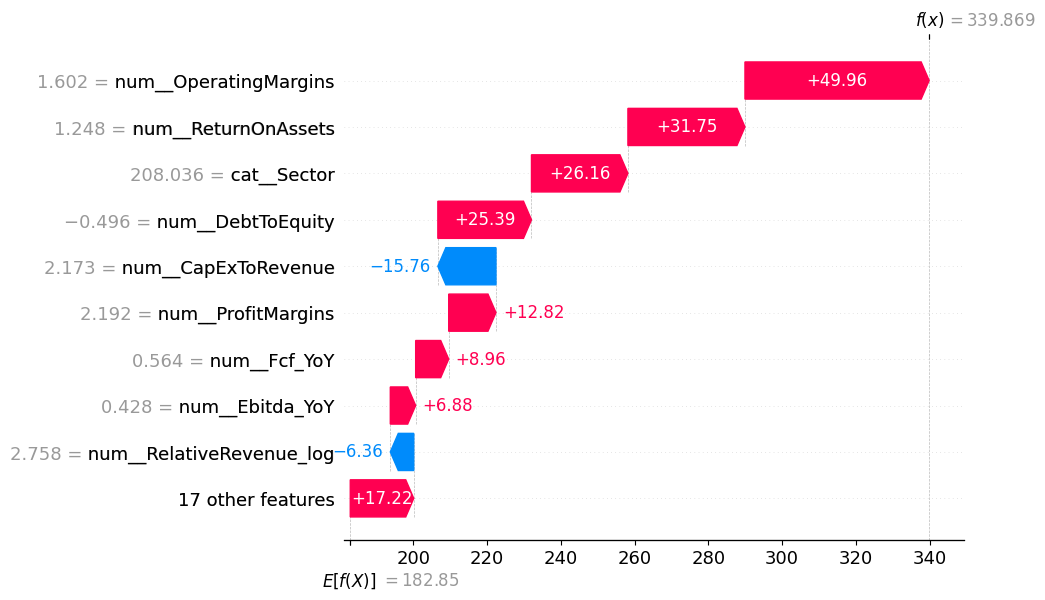

In [14]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiperparámetros

In [15]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)